# Is the trimmed mean's positive-skew underprediction demand-, supply-, or ambiguous-driven?
## And is it consistent across episodes — what does that imply for the current one?

**Framing.** Dallas Fed economists (*"Skewness warrants caution as Trimmed Mean PCE inflation eases"*, April 2026)
show that when the cross-sectional distribution of price changes is **positively skewed**, headline PCE converges
toward **core**, not the **trimmed mean** — i.e. the trimmed mean **underpredicts** headline in these regimes.
This notebook asks three questions the aggregate result can't answer:

1. **Convergence.** In positive-skew months, does headline revert *to* the trimmed mean? We show the trim
   convergence coefficient is **negative at 6-12 months** (headline moves *away* from trim, toward core) and only
   turns **positive at 24 months** (the underprediction reverses).
2. **Attribution.** Is the underprediction coming from **demand**, **supply**, or **ambiguous** price changes —
   using the identity $\pi^H_t-\pi^{TM}_t=\text{Demand}_t+\text{Supply}_t+\text{Ambiguous}_t+\text{Residual}_t$?
3. **Episode consistency & a live inference.** Is the demand/supply/ambiguous mix the **same across positive-skew
   episodes**? If not, we can characterize the **latest** episode: a *supply*-led episode should be more
   **transitory** (supply shocks mean-revert) than a *demand*-led one (which tends to persist).

**Headline findings (preview).** The convergence sign flips as described. The *average* underprediction is a near
even demand/supply split (~43%/46%), but that average **masks large heterogeneity**: 2008 was ~77% supply, 2011-12
~70% demand, 2021-22 a demand/supply tie, and the **current 2025-26 episode is supply-led with ambiguous rising**.
Historically supply-led episodes reverse sharply (transitory) while the demand-led 2021-22 episode's
underprediction persisted a year+. So the current episode leans **transitory** — with the caveats that this rests
on only ~6 episodes and the current episode has no realized forward data yet.

**Conventions.** Trim forward bias $e^{TM}_{t+h}=\pi^H_{t+h}-\pi^{TM}_t>0\Rightarrow$ trim underpredicted.
Newey-West HAC lag $=h+11$. Skew $=$ trailing 12-month Kelly skewness (Dallas-Fed measure). Core PCE pulled from
FRED (PCEPILFE), bundled for reproducibility. Revised data — informational content, not a real-time vintage.

In [1]:
import numpy as np, pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)

DATA_FILE = "Data_Final.xlsx"; SHEET = "Sheet1"
FRED_FILE = "fred_pce_indices.csv"          # bundled FRED indices (PCEPILFE core, PCEPI headline)
SK        = "Kelly_Skewness_12m_avg"        # Dallas-Fed skew measure
HORIZONS  = [6, 12, 24]
def hac_lag(h): return int(h + 11)
def fit_hac(y, X, h):
    return sm.OLS(np.asarray(y, float), np.asarray(X, float)).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lag(h), "use_correction": True})
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
DCOL, SCOL, ACOL, RCOL = "Demand_Gap", "Supply_Gap", "Ambiguous_Gap", "Residual_Gap"


## Data

Load the decomposition file plus the bundled FRED indices, build 12-month core inflation, validate the
constructed headline against the file's `Headline_PCE`, and confirm the adding-up identity.

In [2]:
df = (pd.read_excel(DATA_FILE, sheet_name=SHEET, parse_dates=["Date"])
        .sort_values("Date").reset_index(drop=True))
fred = pd.read_csv(FRED_FILE, parse_dates=["observation_date"]).rename(columns={"observation_date":"Date"})
for src, out in [("PCEPILFE","Core"), ("PCEPI","Head_chk")]:
    fred[out] = 100*(fred[src]/fred[src].shift(12) - 1)
df = df.merge(fred[["Date","Core","Head_chk"]], on="Date", how="left")
df["Gap"] = df["Headline_PCE"] - df["Trimmed_Mean_PCE"]      # = Demand+Supply+Ambiguous+Residual

ok = df.dropna(subset=["Head_chk"])
ident = (df["Gap"] - df[[DCOL,SCOL,ACOL,RCOL]].sum(axis=1)).abs().max()
print(f"rows: {len(df)}   span: {df.Date.min():%Y-%m} .. {df.Date.max():%Y-%m}")
print(f"VALIDATION  corr(constructed headline, file Headline_PCE) = {ok['Headline_PCE'].corr(ok['Head_chk']):.5f}"
      f"   max|diff| = {(ok['Headline_PCE']-ok['Head_chk']).abs().max():.3f}")
print(f"adding-up identity  max|error| = {ident:.2e}")
print(f"positive 12m-skew in {100*(df[SK]>0).mean():.1f}% of months ({(df[SK]>0).sum()} of {len(df)})")

rows: 545   span: 1980-12 .. 2026-04
VALIDATION  corr(constructed headline, file Headline_PCE) = 1.00000   max|diff| = 0.000
adding-up identity  max|error| = 7.17e-14
positive 12m-skew in 11.7% of months (64 of 545)


## 1. Convergence — does headline revert *to* the trimmed mean under positive skew?

$\Delta\pi^H_{t\to t+h}=\alpha+\lambda\,(\pi^{TM}_t-\pi^H_t)+u$ on positive-skew origins. $\lambda>0$ means
headline closes the gap to trim (trim attracts); $\lambda\le 0$ means it does not. We report trim's $\lambda$ both
on its own and controlling for the core gap (the Dallas-Fed horse-race).

,n,lam_trim (solo),t (solo),lam_trim (vs core),t (vs core),lam_core
h,,,,,,
6,59,-0.128,-0.457,-0.768,-2.404,2.593
12,59,0.208,0.530,-0.963,-3.932,4.742
24,59,1.479,6.315,1.057,2.436,1.707


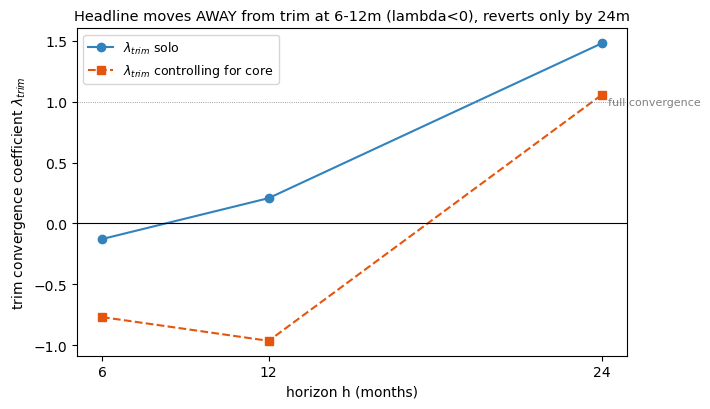

In [3]:
rows = []
for h in HORIZONS:
    d = df.copy(); d["dH"] = d["Headline_PCE"].shift(-h) - d["Headline_PCE"]
    d = d.dropna(subset=["dH", SK, "Core"]); d = d[d[SK] > 0]
    H = d["Headline_PCE"].values
    m_solo = fit_hac(d["dH"].values, sm.add_constant(d["Trimmed_Mean_PCE"].values - H), h)
    g_co = d["Core"].values - H; g_tm = d["Trimmed_Mean_PCE"].values - H
    m_hr = fit_hac(d["dH"].values, sm.add_constant(np.column_stack([g_co, g_tm])), h)
    rows.append({"h": h, "n": len(d),
                 "lam_trim (solo)": m_solo.params[1], "t (solo)": m_solo.tvalues[1],
                 "lam_trim (vs core)": m_hr.params[2], "t (vs core)": m_hr.tvalues[2],
                 "lam_core": m_hr.params[1]})
conv = pd.DataFrame(rows).set_index("h").round(3); display(conv)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(conv.index, conv["lam_trim (solo)"], "o-", color="#3182bd", label=r"$\lambda_{trim}$ solo")
ax.plot(conv.index, conv["lam_trim (vs core)"], "s--", color="#e6550d", label=r"$\lambda_{trim}$ controlling for core")
ax.axhline(0, color="k", lw=.8); ax.axhline(1, color="grey", lw=.6, ls=":")
ax.text(24.2, 1.0, "full convergence", color="grey", fontsize=8, va="center")
ax.set_xticks(HORIZONS); ax.set_xlabel("horizon h (months)")
ax.set_ylabel(r"trim convergence coefficient $\lambda_{trim}$")
ax.set_title("Headline moves AWAY from trim at 6-12m (lambda<0), reverts only by 24m", fontsize=10.5)
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(OUT/"fig_episode_convergence.png", dpi=120, bbox_inches="tight"); plt.show()

**The trimmed mean is not an attractor at 6-12 months.** On its own, trim's $\lambda$ is ~0 at h=6-12 (no
reversion) and only becomes a strong attractor ($\lambda\approx1.5$) at h=24. Controlling for core makes it
**significantly negative at h=6 (−0.77) and h=12 (−0.96)** — headline actively moves *away* from trim, toward core
($\lambda_{core}\approx2.6$-$4.7$) — flipping **positive only at h=24**. The underprediction is a 6-12 month
phenomenon that reverses by two years.

## 2. Attribution — what is the underprediction made of, on average?

Decompose the average positive-skew gap $\pi^H_t-\pi^{TM}_t$ into its demand / supply / ambiguous / residual parts.

In [4]:
pos = df[SK] > 0
g = df.loc[pos, "Gap"].mean()
att = []
for c in [DCOL, SCOL, ACOL, RCOL]:
    v = df.loc[pos, c].mean()
    att.append({"component": c.replace("_Gap",""), "mean (pp)": v, "share of gap (%)": 100*v/g})
print(f"Mean Headline - Trim gap | skew>0 = {g:+.2f} pp   (trim underpredicts)\n")
display(pd.DataFrame(att).set_index("component").round(3))

Mean Headline - Trim gap | skew>0 = +1.31 pp   (trim underpredicts)



,mean (pp),share of gap (%)
component,,
Demand,0.564,43.116
Supply,0.604,46.230
Ambiguous,0.179,13.726
Residual,-0.040,-3.071


On average the underprediction is a **near-even demand/supply split** (~43% demand, ~46% supply, ~14%
ambiguous). But an average over all positive-skew months conceals very different episodes — which is the point of
the next section.

## 3. Episode-by-episode — is the mix consistent? (No.)

Group positive-skew months into episodes (contiguous runs, merging gaps of <=3 months). For each, report the
demand/supply/ambiguous composition, the dominant ("lead") factor, and the **realized forward bias**
$E[\pi^H_{t+h}-\pi^{TM}_t]$ at h=6/12/24 — how persistent the underprediction turned out to be.

In [5]:
p = df[pos].copy()
p["epi"] = (p.index.to_series().diff() > 3).cumsum().values
rows = []
for e, grp in p.groupby("epi"):
    gp = grp["Gap"].mean()
    fwd = {}
    for h in HORIZONS:
        Hf = df["Headline_PCE"].shift(-h)
        fwd[h] = (Hf.loc[grp.index] - df.loc[grp.index, "Trimmed_Mean_PCE"]).mean()
    comp = {k: grp[c].mean() for k, c in [("Demand",DCOL),("Supply",SCOL),("Ambiguous",ACOL)]}
    rows.append({"episode": f"{grp.Date.min():%Y-%m} .. {grp.Date.max():%Y-%m}", "n": len(grp), "gap": gp,
                 "Dem%": 100*comp["Demand"]/gp, "Sup%": 100*comp["Supply"]/gp, "Amb%": 100*comp["Ambiguous"]/gp,
                 "Dem_pp": comp["Demand"], "Sup_pp": comp["Supply"], "Amb_pp": comp["Ambiguous"],
                 "lead": max(comp, key=comp.get),
                 "bias@6": fwd[6], "bias@12": fwd[12], "bias@24": fwd[24]})
ep = pd.DataFrame(rows)
display(ep[["episode","n","gap","Dem%","Sup%","Amb%","lead","bias@6","bias@12","bias@24"]].round(2))

,episode,n,gap,Dem%,Sup%,Amb%,lead,bias@6,bias@12,bias@24
0,1980-12 .. 1981-02,3,1.87,33.11,77.24,-7.68,Supply,0.30,-1.80,-3.93
1,2007-12 .. 2008-09,10,0.97,-2.74,76.85,21.51,Supply,-0.71,-3.24,-0.62
2,2010-03 .. 2010-08,5,1.10,58.65,23.95,15.70,Demand,0.60,1.74,0.86
3,2011-01 .. 2012-04,16,0.77,70.49,30.15,2.16,Demand,0.53,0.02,-0.38
4,2021-01 .. 2023-01,25,1.87,44.64,42.64,18.12,Demand,2.13,1.61,-0.28
5,2025-12 .. 2026-04,5,0.80,44.98,50.48,6.47,Supply,NaN,NaN,NaN


**The factors are not consistent across episodes.** 2007-08 was overwhelmingly **supply** (~77%), 2011-12
overwhelmingly **demand** (~70%), 2021-22 a genuine **demand/supply tie** (45/43 — matching the real-world debate),
and the current 2025-26 episode tilts back to **supply**. And the persistence pattern tracks the lead factor: the
**supply-led** episodes (1980-81, 2007-08) reversed hard (forward bias turns *negative* by 12-24m), while the
**demand-led** 2021-22 episode's underprediction **persisted** (+2.1 pp at h=6, still +1.6 pp at h=12).

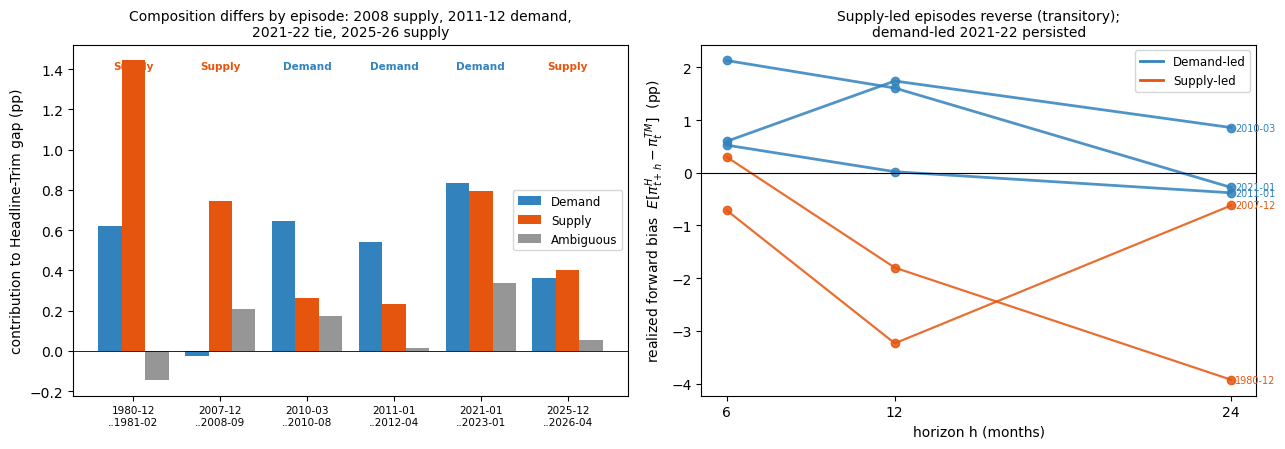

In [6]:
colors = {"Demand": "#3182bd", "Supply": "#e6550d", "Ambiguous": "#969696"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# left: composition (pp) per episode, grouped bars
ax = axes[0]; x = np.arange(len(ep)); w = 0.27
for j, (k, col) in enumerate([("Demand","Dem_pp"),("Supply","Sup_pp"),("Ambiguous","Amb_pp")]):
    ax.bar(x + (j-1)*w, ep[col].values, w, label=k, color=colors[k])
ax.axhline(0, color="k", lw=.6)
ax.set_xticks(x); ax.set_xticklabels([e.replace(" .. ","\n..") for e in ep["episode"]], fontsize=7.5)
ax.set_ylabel("contribution to Headline-Trim gap (pp)")
ax.set_title("Composition differs by episode: 2008 supply, 2011-12 demand,\n2021-22 tie, 2025-26 supply", fontsize=10)
ax.legend(fontsize=8.5)
for xi, lf in zip(x, ep["lead"]):
    ax.text(xi, ax.get_ylim()[1]*0.92, lf, ha="center", fontsize=7.5, fontweight="bold", color=colors[lf])

# right: persistence trajectory (forward bias) per episode, colored by lead factor
ax = axes[1]
for _, r in ep.iterrows():
    ys = [r["bias@6"], r["bias@12"], r["bias@24"]]
    if any(pd.isna(ys)): continue
    ax.plot(HORIZONS, ys, "o-", color=colors[r["lead"]], alpha=0.85,
            label=None, lw=2 if r["lead"]=="Demand" else 1.6)
    ax.annotate(r["episode"][:7], (24, ys[-1]), fontsize=7, color=colors[r["lead"]],
                xytext=(3,0), textcoords="offset points", va="center")
ax.axhline(0, color="k", lw=.8)
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],color=colors["Demand"],lw=2,label="Demand-led"),
                   Line2D([0],[0],color=colors["Supply"],lw=2,label="Supply-led")], fontsize=8.5, loc="upper right")
ax.set_xticks(HORIZONS); ax.set_xlabel("horizon h (months)")
ax.set_ylabel(r"realized forward bias  $E[\pi^H_{t+h}-\pi^{TM}_t]$  (pp)")
ax.set_title("Supply-led episodes reverse (transitory);\ndemand-led 2021-22 persisted", fontsize=10)
fig.tight_layout(); fig.savefig(OUT/"fig_episode_composition.png", dpi=120, bbox_inches="tight"); plt.show()

## 4. The current episode (2025-12 -> 2026-04) and a transitory/persistent read

Recent months: skew turns positive in late 2025 and rises into 2026, and the gap widens sharply — driven by
**supply and ambiguous** accelerating while demand stays roughly flat.

In [7]:
recent = df.tail(9)[["Date", SK, "Gap", DCOL, SCOL, ACOL, "Headline_PCE", "Trimmed_Mean_PCE", "Core"]]
display(recent.round(3).reset_index(drop=True))
cur = df[pos].iloc[-1]
print(f"\nLatest gap (Apr-2026): {df['Gap'].iloc[-1]:+.2f} pp   "
      f"Core-Trim divergence: {(df['Core'].iloc[-1]-df['Trimmed_Mean_PCE'].iloc[-1]):+.2f} pp")
print("Mar-Apr 2026 are supply+ambiguous-led (supply ~+0.5pp, ambiguous +0.3->+0.5pp, demand ~flat +0.4pp).")

,Date,Kelly_Skewness_12m_avg,Gap,Demand_Gap,Supply_Gap,Ambiguous_Gap,Headline_PCE,Trimmed_Mean_PCE,Core
0,2025-08-01,-0.085,-0.050,0.382,-0.215,-0.207,2.748,2.798,2.912
1,2025-09-01,-0.061,0.085,0.351,-0.028,-0.219,2.787,2.702,2.825
2,2025-10-01,-0.052,0.164,0.369,0.012,-0.204,2.713,2.549,2.755
3,2025-11-01,-0.022,0.311,0.382,0.086,-0.175,2.820,2.509,2.829
4,2025-12-01,0.005,0.441,0.289,0.323,-0.171,2.878,2.437,2.971
5,2026-01-01,0.013,0.447,0.412,0.252,-0.219,2.858,2.411,3.086
6,2026-02-01,0.020,0.525,0.309,0.409,-0.190,2.858,2.333,3.032
7,2026-03-01,0.074,1.169,0.358,0.501,0.327,3.525,2.356,3.236
8,2026-04-01,0.113,1.422,0.434,0.536,0.512,3.767,2.345,3.289



Latest gap (Apr-2026): +1.42 pp   Core-Trim divergence: +0.94 pp
Mar-Apr 2026 are supply+ambiguous-led (supply ~+0.5pp, ambiguous +0.3->+0.5pp, demand ~flat +0.4pp).


**Inference.** The current episode is **supply-led with ambiguous rising** — the same signature as the
*transitory* 2007-08 episode, not the *persistent* demand-led 2021-22 one. By the historical regularity
(supply-led -> sharp reversal), the present trim underprediction is **more likely to reverse** (headline falling
back toward trim by ~18-24 months) than to drag on the way 2021-22 did. This is consistent with the Dallas-Fed
note, which flags **supply** disruptions (Middle East) as the recurrence risk — and supply shocks mean-revert.

**Caveats (important).**
- **~6 episodes total.** The supply->transitory regularity rests on 2 supply episodes vs 1 persistent demand
  episode; it is a suggestive historical pattern, not a tested law.
- **2007-08's reversal was amplified by the GFC** (an exogenous demand collapse), overstating pure
  supply mean-reversion.
- **No forward data on the current episode** — persistence is inferred from composition + history, not observed.
- **Ambiguous is large and rising** in the latest prints (~a third of the April gap); the "supply" read carries
  genuine classification uncertainty.

## Conclusion

**What is the trimmed mean's positive-skew underprediction, and is it the same each time?**

1. **Convergence.** Under positive skew the trimmed mean is *not* an attractor at 6-12 months (headline moves
   toward core, $\lambda_{trim}<0$ controlling for core); it reverts to trim only by 24 months.
2. **Attribution.** On average the underprediction is ~43% demand / ~46% supply / ~14% ambiguous — but this hides
   large episode heterogeneity.
3. **Episodes differ — and that is the usable signal.** 2007-08 supply, 2011-12 demand, 2021-22 a tie, 2025-26
   supply. Supply-led episodes reverse (transitory); the demand-led 2021-22 episode persisted a year+.
4. **Current read.** The 2025-26 episode is supply/ambiguous-led, so it **leans transitory** — subject to the
   small-sample and no-forward-data caveats above.

**Why this matters.** Neither the trimmed mean nor core can tell you *what kind* of positive-skew divergence is
underway. The demand/supply/ambiguous decomposition can — turning the Dallas-Fed caution into a **real-time read on
whether the current trim underprediction is the transitory-supply kind or the sticky-demand kind.**